# N4 — Ferramentas

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a> 

Introzimos **tools**. A ideia central é entender como um agente pode ampliar sua capacidade operacional usando funções externas, como APIs, bancos de dados, calculadoras, sistemas internos e serviços computacionais.

O ponto mais importante da aula é:

> a LLM não executa a ferramenta diretamente.  
> a LLM decide que ferramenta chamar.

> A LLM  **solicita** uma chamada de ferramenta.  
> O código da aplicação executa a ferramenta e devolve o resultado para a LLM como uma `ToolMessage`.

Esse padrão é a base de agentes do tipo **ReAct** (aprenderemos mais sobre isso em reasoning), isto é, agentes que alternam entre raciocinar, escolher uma ação, observar o resultado e continuar até produzir uma resposta final.

Ao longo deste notebook, o agente será tratado como um assistente do curso de LangGraph. Ele poderá consultar o cronograma dos módulos, verificar o progresso de alunos e calcular planos de estudo.



## 0.1 Pré-requisitos

Para acompanhar este notebook, é esperado que você já tenha:

- concluído ou entendido as aulas anteriores de LangGraph;
- noções básicas de LangChain;
- noções de mensagens conversacionais, como `HumanMessage`, `SystemMessage` e `AIMessage`;
- noções de funções Python;
- noções básicas de JSON;
- familiaridade mínima com APIs ou bancos de dados.

## 0.2 Objetivos da aula

Ao final deste notebook, você deverá saber:

1. Definir ferramentas com LangChain usando `@tool`.
2. Entender o papel do nome, descrição e schema de argumentos de uma tool.
3. Diferenciar uma **solicitação de tool** de uma **execução de tool**.
4. Entender o que é uma `ToolMessage`.
5. Executar manualmente uma tool solicitada por uma `AIMessage`.
6. Conectar tools a uma LLM com `bind_tools`.
7. Construir um loop ReAct simples com LangChain.
8. Modelar tools que simulam API, banco de dados e serviço computacional no contexto de um curso de LangGraph.
9. Recriar o fluxo LLM → tool → LLM dentro de um grafo LangGraph.
10. Usar um agente pronto com `create_agent`.


## 0.3 Mapa do notebook

Neste notebook, vamos construir progressivamente:

1. A premissa: tool calling não é execução automática.
2. Uma primeira tool com LangChain usando um exemplo de carga horária do curso.
3. Uma `AIMessage` com `tool_calls`.
4. Uma `ToolMessage` criada após executar a tool.
5. Um modelo de chat conectado a tools.
6. Tools simulando uma API de cronograma, um banco de progresso de alunos e um serviço de planejamento de estudo.
7. Um loop ReAct manual com LangChain.
8. O mesmo padrão usando LangGraph.
9. Um agente pronto com `create_agent`.
10. Exercícios de fixação.


## 0.4 Contexto usado nos exemplos

Para manter a continuidade com os notebooks anteriores, os exemplos deste notebook usam o seguinte cenário:

- existe um **curso de LangGraph** organizado em módulos;
- o módulo **A4** introduz estado, nós e transições;
- o módulo **A5** explora workflows completos com LLM, condicionais e loops;
- o módulo **A6** introduz tools e agentes ReAct;
- o agente deve auxiliar alunos a consultar cronograma, progresso e próximos passos de estudo.

Esse contexto é propositalmente simples, mas representa um padrão comum em agentes reais:

- consultar uma API externa;
- consultar dados estruturados em um banco;
- executar um cálculo ou serviço computacional;
- interpretar os resultados para produzir uma resposta útil.

---

## 0.5 Preparação do ambiente

Este notebook assume que você já tem LangChain, LangGraph e um provedor de LLM configurados.

Para manter a continuidade com os notebooks anteriores, os exemplos usam `init_chat_model`.

> Importante: para os exemplos com `bind_tools`, escolha um modelo que suporte **tool calling**.  
> Em Ollama, por exemplo, use um modelo preparado para tools. Caso contrário, `ai_response.tool_calls` pode vir vazio.


In [28]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langchain langchain-core langgraph langchain-ollama pydantic rich

   ---------------------------------------- 0.0/247.0 kB ? eta -:--:--
   ----------- ---------------------------- 71.7/247.0 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 247.0/247.0 kB 3.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/310.7 kB ? eta -:--:--
   ---------------------------------------- 310.7/310.7 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: rich
    Found existing installation: rich 13.9.4
    Uninstalling rich-13.9.4:
      Successfully uninstalled rich-13.9.4
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.7
    Uninstalling langgraph-1.2.7:
      Successfully uninstalled langgraph-1.2.7
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
together 1.5.2 requires rich<14.0.0,>=13.8.1, but you have rich 15.0.0 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Agora importamos os elementos que serão usados ao longo da aula.

In [54]:
from typing import Annotated, TypedDict, Literal
import json
import math
import sqlite3

from langchain.chat_models import init_chat_model
from langchain.tools import tool as tool_decorator
from langchain.agents import create_agent
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph

from IPython.display import Image, display
from rich import print
from rich.markdown import Markdown


Esses imports combinam elementos de três níveis:

- **LangChain Core**: mensagens, tools e modelo de chat;
- **LangChain Agents**: harness pronto para agentes com tools;
- **LangGraph**: orquestração explícita do loop agente → tool → agente.

In [30]:
def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_messages(messages: list[BaseMessage]) -> None:
    """Imprime uma conversa de maneira compacta."""
    for index, message in enumerate(messages):
        print(f"\n[bold]Mensagem {index} — {message.__class__.__name__}[/bold]")
        if isinstance(message, AIMessage) and message.tool_calls:
            print("[yellow]tool_calls:[/yellow]")
            print(message.tool_calls)
        else:
            print(message.content)


def to_tool_content(value) -> str:
    """Converte o retorno de uma tool para string segura para ToolMessage."""
    if isinstance(value, str):
        return value

    return json.dumps(value, ensure_ascii=False)

Agora inicializamos o modelo.

Substitua `MODEL_ID` pelo modelo configurado no seu ambiente.  
O ponto importante é que ele precisa suportar **tool calling** para as seções que usam `bind_tools`.

Exemplos possíveis, dependendo do seu ambiente:

- `"ollama:gpt-oss:20b"`;
- `"openai:gpt-4o-mini"`;
- `"anthropic:claude-sonnet-4-5"`;
- `"google_genai:gemini-2.5-flash"`.

Os exemplos manuais de `ToolMessage` funcionam mesmo sem chamar uma LLM.

In [44]:
#MODEL_ID = "ollama:gpt-oss:20b"
#llm = init_chat_model(MODEL_ID, temperature=0)
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
import os
# Instancia o modelo da OpenAI via API — segundo EXEMPLO de provedor via API.
load_dotenv()
print("Chave OPENAI_API_KEY configurada com sucesso." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")
llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

Chave OPENAI_API_KEY configurada com sucesso.

# 1. Premissa da aula: a LLM não executa a tool

Uma confusão comum é pensar que a LLM executa ferramentas externas.

Na prática, o fluxo é este:

1. O usuário faz uma pergunta.
2. A aplicação envia a pergunta para a LLM.
3. A LLM decide se precisa usar uma ferramenta.
4. Se precisar, a LLM retorna uma `AIMessage` contendo `tool_calls`.
5. A aplicação Python lê esses `tool_calls`.
6. A aplicação Python executa a função correspondente.
7. O resultado da função é colocado em uma `ToolMessage`.
8. A aplicação envia novamente o histórico para a LLM.
9. A LLM interpreta o resultado e produz a resposta final.

Portanto:

- `AIMessage.tool_calls` representa uma **intenção de chamada**;
- `ToolMessage` representa uma **observação obtida após execução real da ferramenta**;
- a execução é feita pelo runtime da aplicação, não pelo modelo.

No contexto do nosso curso de LangGraph, isso significa que o modelo pode pedir algo como:

> consulte o cronograma do módulo A6

Mas quem realmente acessa o cronograma é a aplicação Python, por meio de uma tool.


# 2. Primeira tool com LangChain

Vamos começar com uma ferramenta simples no contexto do curso.

A ferramenta abaixo calcula a carga horária total de uma sequência de aulas.

A ferramenta é apenas uma função Python decorada com `@tool`.

A docstring e os type hints são importantes porque ajudam o modelo a entender:

- o que a ferramenta faz;
- quando usá-la;
- quais argumentos ela espera.


In [61]:
@tool_decorator
def calcular_carga_total(quantidade_aulas: int, minutos_por_aula: int) -> str:
    """Calcula a carga horária total de aulas do curso de LangGraph.

    Use quando for necessário calcular a duração total de aulas, módulos ou trilhas do curso.
    """
    total_minutos = quantidade_aulas * minutos_por_aula
    horas = total_minutos // 60
    minutos = total_minutos % 60

    return json.dumps(
        {
            "quantidade_aulas": quantidade_aulas,
            "minutos_por_aula": minutos_por_aula,
            "total_minutos": total_minutos,
            "total_formatado": f"{horas}h{minutos:02d}min",
        },
        ensure_ascii=False,
    )


Podemos inspecionar os metadados da tool.

Essa função poderia ser usada por um assistente do curso quando um aluno pergunta, por exemplo:

> Qual é a carga total de 6 aulas de 50 minutos?

Mesmo sendo uma operação simples, ela nos permite observar com clareza a estrutura de uma tool.


In [36]:
print("Nome da tool:", calcular_carga_total.name)
print("Descrição:", calcular_carga_total.description)
print("Schema de argumentos:")
print(calcular_carga_total.args)


Nome da tool: calcular_carga_total

Descrição: Calcula a carga horária total de aulas do curso de LangGraph.

    Use quando for necessário calcular a duração total de aulas, módulos ou trilhas do curso.

Schema de argumentos:

{
    'quantidade_aulas': {'title': 'Quantidade Aulas', 'type': 'integer'},
    'minutos_por_aula': {'title': 'Minutos Por Aula', 'type': 'integer'}
}

Também podemos executar a tool diretamente, sem LLM.


In [37]:
resultado = calcular_carga_total.invoke({"quantidade_aulas": 6, "minutos_por_aula": 50})
print(resultado)


{"quantidade_aulas": 6, "minutos_por_aula": 50, "total_minutos": 300, "total_formatado": "5h00min"}

Nesse ponto, ainda não temos agente.

Temos apenas uma função Python padronizada no formato que LangChain consegue apresentar a um modelo de chat.


# 3. Simulando uma solicitação de tool pela LLM

Agora vamos simular manualmente uma resposta da LLM.

A mensagem abaixo representa uma LLM dizendo:

> "Para responder, eu gostaria que a ferramenta `calcular_carga_total` fosse chamada com `quantidade_aulas=6` e `minutos_por_aula=50`."

Observe que isso **não executa** a função.

A mensagem apenas descreve uma chamada desejada.


In [38]:
ai_message = AIMessage(
    content="",
    tool_calls=[
        {
            "name": "calcular_carga_total",
            "args": {"quantidade_aulas": 6, "minutos_por_aula": 50},
            "id": "call_carga_001",
            "type": "tool_call",
        }
    ],
)

print(type(ai_message))
print(ai_message.tool_calls)


<class 'langchain_core.messages.ai.AIMessage'>

[
    {
        'name': 'calcular_carga_total',
        'args': {'quantidade_aulas': 6, 'minutos_por_aula': 50},
        'id': 'call_carga_001',
        'type': 'tool_call'
    }
]

A `AIMessage` contém uma lista chamada `tool_calls`.

Cada item dessa lista normalmente contém:

- `name`: nome da ferramenta solicitada;
- `args`: argumentos que devem ser passados para a ferramenta;
- `id`: identificador único da chamada;
- `type`: tipo da chamada.

Esse `id` será usado para conectar a solicitação da LLM ao resultado da ferramenta.

# 4. Criando uma `ToolMessage`

Agora vamos executar a tool manualmente.

Esse é o papel da aplicação: ler `tool_calls`, localizar a função correta, executar a função e criar uma `ToolMessage`.

In [62]:
tools = [calcular_carga_total]
tools_by_name = {registered_tool.name: registered_tool for registered_tool in tools}

tool_call = ai_message.tool_calls[0]

tool_name = tool_call["name"]
tool_args = tool_call["args"]

selected_tool = tools_by_name[tool_name]
observation = selected_tool.invoke(tool_args)

tool_message = ToolMessage(
    content=str(observation),
    tool_call_id=tool_call["id"],
)

print(type(tool_message))
print(tool_message)


<class 'langchain_core.messages.tool.ToolMessage'>

ToolMessage(
    content='{"quantidade_aulas": 6, "minutos_por_aula": 50, "total_minutos": 300, "total_formatado": "5h00min"}',
    tool_call_id='call_carga_001'
)

A `ToolMessage` é a mensagem que transporta o resultado da execução da ferramenta de volta para o modelo.

Repare em dois campos importantes:

- `content`: resultado da ferramenta;
- `tool_call_id`: identificador da chamada original feita pela LLM.

O `tool_call_id` precisa corresponder ao `id` da chamada de tool dentro da `AIMessage`.

In [40]:
print("Conteúdo da ToolMessage:", tool_message.content)
print("ID associado:", tool_message.tool_call_id)

Conteúdo da ToolMessage: {"quantidade_aulas": 6, "minutos_por_aula": 50, "total_minutos": 300, "total_formatado": 
"5h00min"}

ID associado: call_carga_001

Agora podemos montar o histórico completo:

1. `HumanMessage`: pergunta do usuário;
2. `AIMessage`: pedido de chamada de ferramenta;
3. `ToolMessage`: resultado da ferramenta.

Esse histórico é o que a LLM precisa receber para interpretar a observação e formular uma resposta final.

In [41]:
messages = [
    HumanMessage(content="Qual é a carga total de 6 aulas de 50 minutos do curso?"),
    ai_message,
    tool_message,
]

print_messages(messages)


Mensagem 0 — HumanMessage

Qual é a carga total de 6 aulas de 50 minutos do curso?

Mensagem 1 — AIMessage

tool_calls:

[
    {
        'name': 'calcular_carga_total',
        'args': {'quantidade_aulas': 6, 'minutos_por_aula': 50},
        'id': 'call_carga_001',
        'type': 'tool_call'
    }
]

Mensagem 2 — ToolMessage

{"quantidade_aulas": 6, "minutos_por_aula": 50, "total_minutos": 300, "total_formatado": "5h00min"}

# 5. Conectando tools a uma LLM com `bind_tools`

Agora vamos deixar que o próprio modelo decida se quer chamar a ferramenta.

Para isso, usamos `bind_tools`.

`bind_tools` não executa a tool.  
Ele apenas informa ao modelo quais ferramentas estão disponíveis e quais schemas elas possuem.

In [46]:
llm_with_tools = llm.bind_tools(tools)

Vamos fazer uma pergunta que provavelmente deve acionar a tool `calcular_carga_total`.


In [48]:
user_messages = [
    HumanMessage(
        content=(
            "No curso de LangGraph, qual é a carga total de 4 aulas "
            "com 45 minutos cada? Use uma ferramenta se isso ajudar."
        )
    )
]

ai_response = llm_with_tools.invoke(user_messages)

print(type(ai_response))
print("Conteúdo textual:", ai_response.content)
print("Tool calls:")
print(ai_response.tool_calls)


<class 'langchain_core.messages.ai.AIMessage'>

Conteúdo textual:

Tool calls:

[
    {
        'name': 'calcular_carga_total',
        'args': {'quantidade_aulas': 4, 'minutos_por_aula': 45},
        'id': 'call_BgwVeXx8j22YZMqlSzwFS9U3',
        'type': 'tool_call'
    }
]

Se o modelo decidiu usar uma ferramenta, `ai_response.tool_calls` terá pelo menos um item.

Se vier vazio, as causas mais comuns são:

- o modelo escolhido não suporta tool calling;
- o modelo decidiu responder sem ferramenta;
- a pergunta não deixou claro que a ferramenta era útil.

Agora executamos a tool solicitada e devolvemos uma `ToolMessage` para o modelo.

In [63]:
tool_messages = []

for tool_call in ai_response.tool_calls:
    selected_tool = tools_by_name[tool_call["name"]]
    observation = selected_tool.invoke(tool_call["args"])

    tool_messages.append(
        ToolMessage(
            content=to_tool_content(observation),
            tool_call_id=tool_call["id"],
        )
    )

if tool_messages:
    final_response = llm_with_tools.invoke(
        user_messages + [ai_response] + tool_messages
    )

    print(Markdown(final_response.content))
else:
    print("O modelo não solicitou nenhuma tool nesta execução.")


A carga total de 4 aulas com 45 minutos cada é de 180 minutos, o que equivale a 3 horas.

## Discussão

O mecanismo central de tool calling:

```text
Usuário
  ↓
LLM com tools disponíveis
  ↓
AIMessage com tool_calls
  ↓
Aplicação executa a função Python
  ↓
ToolMessage com observação
  ↓
LLM interpreta a observação
  ↓
Resposta final
```

A LLM participa da decisão e da interpretação.

A aplicação participa da execução e do controle.

No contexto do exemplo, isso significa que a LLM pode solicitar dados de carga horária, cronograma ou progresso, mas a execução real fica sob responsabilidade do sistema.


# 6. Tools como APIs, bancos de dados e serviços computacionais

Agora vamos ampliar o exemplo para um cenário mais próximo dos notebooks anteriores.

Imagine um assistente do curso de LangGraph que pode:

1. consultar uma **API simulada** de cronograma dos módulos;
2. consultar um **banco de dados simulado** de progresso dos alunos;
3. executar um **serviço computacional** para montar um plano de estudo.

Esse conjunto representa um padrão comum em agentes reais:

- a LLM decide que precisa de uma informação;
- a aplicação chama uma ferramenta externa;
- o resultado volta como `ToolMessage`;
- a LLM interpreta o resultado.


## 6.1 Tool simulando uma API de cronograma

A primeira tool simula uma API do curso.

Ela recebe o código de um módulo, como `A4`, `A5` ou `A6`, e retorna informações do cronograma.


In [65]:
@tool_decorator
def consultar_cronograma_modulo(codigo_modulo: str) -> str:
    """Consulta o cronograma simulado de um módulo do curso de LangGraph.

    Use quando o usuário perguntar sobre tema, objetivo, duração, pré-requisitos ou entrega de um módulo.
    """
    cronograma = {
        "A4": {
            "codigo": "A4",
            "titulo": "Conceitos básicos de LangGraph",
            "descricao": "Estado, nós, transições e modelagem estruturada de fluxos de agentes.",
            "pre_requisitos": [],
            "duracao_estimada_min": 90,
            "entregavel": "Notebook com grafo mínimo usando StateGraph.",
        },
        "A5": {
            "codigo": "A5",
            "titulo": "LangGraph com LLM",
            "descricao": "Workflows completos com estados compartilhados, condicionais e loops de interação.",
            "pre_requisitos": ["A4"],
            "duracao_estimada_min": 120,
            "entregavel": "Notebook com workflow de agente usando LLM.",
        },
        "A6": {
            "codigo": "A6",
            "titulo": "Tools e agentes ReAct",
            "descricao": "Integração de agentes com ferramentas externas, ToolMessage e loops ReAct.",
            "pre_requisitos": ["A4", "A5"],
            "duracao_estimada_min": 150,
            "entregavel": "Notebook com agente capaz de chamar tools e interpretar observações.",
        },
    }

    chave = codigo_modulo.strip().upper()
    resultado = cronograma.get(chave)

    if resultado is None:
        return json.dumps(
            {
                "erro": "modulo_nao_encontrado",
                "modulo_solicitado": codigo_modulo,
                "modulos_disponiveis": list(cronograma.keys()),
            },
            ensure_ascii=False,
        )

    return json.dumps(resultado, ensure_ascii=False)


## 6.2 Tool simulando banco de dados de progresso

A segunda tool consulta um banco SQLite em memória.

Esse banco representa um sistema acadêmico simples com alunos e progresso por módulo.


In [66]:
conn = sqlite3.connect(":memory:")

conn.execute("DROP TABLE IF EXISTS alunos")
conn.execute("DROP TABLE IF EXISTS progresso_modulos")

conn.execute(
    """
    CREATE TABLE alunos (
        id INTEGER PRIMARY KEY,
        nome TEXT NOT NULL,
        email TEXT NOT NULL
    )
    """
)

conn.execute(
    """
    CREATE TABLE progresso_modulos (
        aluno_id INTEGER NOT NULL,
        modulo TEXT NOT NULL,
        status TEXT NOT NULL,
        percentual INTEGER NOT NULL,
        observacao TEXT,
        FOREIGN KEY (aluno_id) REFERENCES alunos(id)
    )
    """
)

conn.executemany(
    "INSERT INTO alunos (nome, email) VALUES (?, ?)",
    [
        ("Renan", "renan@example.com"),
        ("Ana", "ana@example.com"),
        ("Bruno", "bruno@example.com"),
    ],
)

conn.executemany(
    """
    INSERT INTO progresso_modulos
    (aluno_id, modulo, status, percentual, observacao)
    VALUES (?, ?, ?, ?, ?)
    """,
    [
        (1, "A4", "concluido", 100, "Entendeu estado, nós e transições."),
        (1, "A5", "concluido", 100, "Construiu workflow com LLM e condicionais."),
        (1, "A6", "nao_iniciado", 0, "Próximo módulo recomendado."),
        (2, "A4", "concluido", 100, "Bom domínio do grafo básico."),
        (2, "A5", "em_andamento", 50, "Ainda revisando loops e rotas condicionais."),
        (2, "A6", "bloqueado", 0, "Depende da conclusão do A5."),
        (3, "A4", "em_andamento", 70, "Precisa revisar reducers."),
        (3, "A5", "nao_iniciado", 0, "Aguardando finalização do A4."),
        (3, "A6", "bloqueado", 0, "Depende de A4 e A5."),
    ],
)

conn.commit()


In [67]:
@tool_decorator
def consultar_progresso_aluno(aluno: str) -> str:
    """Consulta o progresso de um aluno nos módulos do curso de LangGraph.

    Use quando o usuário perguntar quais módulos um aluno concluiu, está cursando ou deve estudar em seguida.
    """
    termo = f"%{aluno.strip().lower()}%"

    cursor = conn.execute(
        """
        SELECT a.nome, a.email, p.modulo, p.status, p.percentual, p.observacao
        FROM alunos a
        JOIN progresso_modulos p ON p.aluno_id = a.id
        WHERE lower(a.nome) LIKE ?
        OR lower(a.email) LIKE ?
        ORDER BY p.modulo ASC
        """,
        (termo, termo),
    )

    linhas = cursor.fetchall()

    if not linhas:
        return json.dumps(
            {
                "erro": "aluno_nao_encontrado",
                "aluno_solicitado": aluno,
            },
            ensure_ascii=False,
        )

    resultado = {
        "aluno": linhas[0][0],
        "email": linhas[0][1],
        "modulos": [
            {
                "modulo": modulo,
                "status": status,
                "percentual": percentual,
                "observacao": observacao,
            }
            for _, _, modulo, status, percentual, observacao in linhas
        ],
    }

    return json.dumps(resultado, ensure_ascii=False)


## 6.3 Tool simulando serviço computacional

A terceira tool executa uma pequena lógica de planejamento.

Ela recebe a duração estimada de um módulo e a disponibilidade diária do aluno.

Esse tipo de tool representa serviços que fazem cálculo, otimização, validação, ranqueamento ou transformação de dados.


In [70]:
@tool_decorator
def calcular_plano_estudo(carga_minutos: int, minutos_disponiveis_por_dia: int) -> str:
    """Calcula um plano de estudo para concluir um módulo do curso de LangGraph.

    Use quando for necessário transformar a duração estimada de um módulo em um plano de estudo diário.
    """
    if carga_minutos <= 0:
        return json.dumps(
            {
                "erro": "carga_invalida",
                "mensagem": "A carga do módulo deve ser maior que zero.",
            },
            ensure_ascii=False,
        )

    if minutos_disponiveis_por_dia <= 0:
        return json.dumps(
            {
                "erro": "disponibilidade_invalida",
                "mensagem": "A disponibilidade diária deve ser maior que zero.",
            },
            ensure_ascii=False,
        )

    dias_necessarios = math.ceil(carga_minutos / minutos_disponiveis_por_dia)
    ultima_sessao_min = carga_minutos % minutos_disponiveis_por_dia

    if ultima_sessao_min == 0:
        ultima_sessao_min = minutos_disponiveis_por_dia

    return json.dumps(
        {
            "carga_total_minutos": carga_minutos,
            "minutos_disponiveis_por_dia": minutos_disponiveis_por_dia,
            "dias_necessarios": dias_necessarios,
            "ultima_sessao_minutos": ultima_sessao_min,
            "sugestao": (
                f"Estude por {dias_necessarios} dia(s), mantendo sessões de "
                f"até {minutos_disponiveis_por_dia} minutos."
            ),
        },
        ensure_ascii=False,
    )


Agora agrupamos as tools operacionais.

In [71]:
tools_operacionais = [
    consultar_cronograma_modulo,
    consultar_progresso_aluno,
    calcular_plano_estudo,
]

tools_operacionais_by_name = {
    registered_tool.name: registered_tool for registered_tool in tools_operacionais
}

for registered_tool in tools_operacionais:
    print(f"\n[bold]{registered_tool.name}[/bold]")
    print(registered_tool.description)
    print(registered_tool.args)


consultar_cronograma_modulo

Consulta o cronograma simulado de um módulo do curso de LangGraph.

    Use quando o usuário perguntar sobre tema, objetivo, duração, pré-requisitos ou entrega de um módulo.

{'codigo_modulo': {'title': 'Codigo Modulo', 'type': 'string'}}

consultar_progresso_aluno

Consulta o progresso de um aluno nos módulos do curso de LangGraph.

    Use quando o usuário perguntar quais módulos um aluno concluiu, está cursando ou deve estudar em seguida.

{'aluno': {'title': 'Aluno', 'type': 'string'}}

calcular_plano_estudo

Calcula um plano de estudo para concluir um módulo do curso de LangGraph.

    Use quando for necessário transformar a duração estimada de um módulo em um plano de estudo diário.

{
    'carga_minutos': {'title': 'Carga Minutos', 'type': 'integer'},
    'minutos_disponiveis_por_dia': {'title': 'Minutos Disponiveis Por Dia', 'type': 'integer'}
}

## Discussão

As três tools têm naturezas diferentes:

| Tipo de tool | Exemplo | Papel |
|---|---|---|
| API externa | `consultar_cronograma_modulo` | Buscar dados do cronograma fora do contexto interno da LLM |
| Banco de dados | `consultar_progresso_aluno` | Consultar estado de um sistema acadêmico |
| Serviço computacional | `calcular_plano_estudo` | Executar cálculo determinístico de planejamento |

Em todos os casos, a LLM não executa o código.  
Ela apenas solicita a chamada.  
A aplicação executa a tool e devolve o resultado.

Em um sistema real, essas tools poderiam acessar:

- APIs REST;
- bancos PostgreSQL, SQLite ou vetoriais;
- serviços internos;
- scripts de análise;
- sistemas de arquivos;
- filas de processamento;
- sistemas de autorização.


# 7. Decisão de uso de tools

Agora vamos conectar essas tools ao modelo.

O prompt de sistema deve deixar claro quando usar tools e como interpretar seus resultados.

In [72]:
SYSTEM_TOOLS_PROMPT = """
Você é um assistente técnico de um curso de LangGraph.

O curso está organizado em módulos como A4, A5 e A6.
Você ajuda alunos a consultar cronograma, entender pré-requisitos,
verificar progresso e montar planos de estudo.

Regras:
- Use tools quando a pergunta exigir dado do cronograma, progresso de aluno ou cálculo exato de planejamento.
- Não invente status de progresso, duração de módulo ou pré-requisitos.
- Quando uma tool retornar JSON, interprete o JSON antes de responder.
- Se uma tool retornar erro, explique o erro de forma objetiva.
- Não diga que você executou a ferramenta por conta própria; a ferramenta foi executada pelo sistema da aplicação.
"""

llm_operacional = llm.bind_tools(tools_operacionais)


Vamos criar uma função auxiliar para executar todas as `tool_calls` de uma `AIMessage`.

In [74]:
def executar_tool_calls(ai_message: AIMessage) -> list[ToolMessage]:
    """Executa as tool calls solicitadas por uma AIMessage."""
    tool_messages = []

    for tool_call in ai_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_call_id = tool_call["id"]

        if tool_name not in tools_operacionais_by_name:
            observation = {
                "erro": "tool_desconhecida",
                "tool_solicitada": tool_name,
                "tools_disponiveis": list(tools_operacionais_by_name.keys()),
            }
        else:
            try:
                tool = tools_operacionais_by_name[tool_name]
                observation = tool.invoke(tool_args)
            except Exception as error:
                observation = {
                    "erro": "falha_na_execucao_da_tool",
                    "tool": tool_name,
                    "mensagem": str(error),
                }

        tool_messages.append(
            ToolMessage(
                content=to_tool_content(observation),
                tool_call_id=tool_call_id,
            )
        )

    return tool_messages

Agora fazemos uma chamada ao modelo e observamos se ele solicita alguma tool.

In [75]:
messages = [
    SystemMessage(content=SYSTEM_TOOLS_PROMPT),
    HumanMessage(
        content=(
            "Sou o aluno Renan. Verifique meu progresso no curso, consulte o cronograma "
            "do módulo A6 e monte um plano considerando 45 minutos de estudo por dia."
        )
    ),
]

ai_response = llm_operacional.invoke(messages)

print("Conteúdo textual:")
print(ai_response.content)

print("\nTool calls:")
print(ai_response.tool_calls)


Conteúdo textual:

Tool calls:

[
    {
        'name': 'consultar_progresso_aluno',
        'args': {'aluno': 'Renan'},
        'id': 'call_JBTDmxZ9IQTtlZyRPdqNrg8E',
        'type': 'tool_call'
    },
    {
        'name': 'consultar_cronograma_modulo',
        'args': {'codigo_modulo': 'A6'},
        'id': 'call_xpP2pue0P37GzNXnMCVSNZub',
        'type': 'tool_call'
    },
    {
        'name': 'consultar_cronograma_modulo',
        'args': {'codigo_modulo': 'A6'},
        'id': 'call_ya6FT5sYk4h09JA0XJuNrzQF',
        'type': 'tool_call'
    }
]

Se houver chamadas de tool, executamos e devolvemos as observações para a LLM.

In [76]:
tool_messages = executar_tool_calls(ai_response)

print_messages([ai_response, *tool_messages])

Mensagem 0 — AIMessage

tool_calls:

[
    {
        'name': 'consultar_progresso_aluno',
        'args': {'aluno': 'Renan'},
        'id': 'call_JBTDmxZ9IQTtlZyRPdqNrg8E',
        'type': 'tool_call'
    },
    {
        'name': 'consultar_cronograma_modulo',
        'args': {'codigo_modulo': 'A6'},
        'id': 'call_xpP2pue0P37GzNXnMCVSNZub',
        'type': 'tool_call'
    },
    {
        'name': 'consultar_cronograma_modulo',
        'args': {'codigo_modulo': 'A6'},
        'id': 'call_ya6FT5sYk4h09JA0XJuNrzQF',
        'type': 'tool_call'
    }
]

Mensagem 1 — ToolMessage

{"aluno": "Renan", "email": "renan@example.com", "modulos": [{"modulo": "A4", "status": "concluido", "percentual": 
100, "observacao": "Entendeu estado, nós e transições."}, {"modulo": "A5", "status": "concluido", "percentual": 
100, "observacao": "Construiu workflow com LLM e condicionais."}, {"modulo": "A6", "status": "nao_iniciado", 
"percentual": 0, "observacao": "Próximo módulo recomendado."}]}

Mensagem 2 — ToolMessage

{"codigo": "A6", "titulo": "Tools e agentes ReAct", "descricao": "Integração de agentes com ferramentas externas, 
ToolMessage e loops ReAct.", "pre_requisitos": ["A4", "A5"], "duracao_estimada_min": 150, "entregavel": "Notebook 
com agente capaz de chamar tools e interpretar observações."}

Mensagem 3 — ToolMessage

{"codigo": "A6", "titulo": "Tools e agentes ReAct", "descricao": "Integração de agentes com ferramentas externas, 
ToolMessage e loops ReAct.", "pre_requisitos": ["A4", "A5"], "duracao_estimada_min": 150, "entregavel": "Notebook 
com agente capaz de chamar tools e interpretar observações."}

In [77]:
if tool_messages:
    final_response = llm_operacional.invoke(
        messages + [ai_response] + tool_messages
    )

    print(Markdown(final_response.content))
else:
    print("O modelo não solicitou nenhuma tool nesta execução.")

## Discussão

A decisão de usar ferramentas depende de três elementos:

1. **Descrição da tool**  
   O modelo precisa entender para que a tool serve.

2. **Prompt de sistema**  
   O prompt define a política de uso: quando usar, quando não usar, como lidar com erros.

3. **Pergunta do usuário**  
   Perguntas sobre dados do curso, estado de progresso ou cálculo exato tendem a justificar tools.

Em um agente educacional, isso é especialmente importante: o modelo não deve inventar que um aluno concluiu um módulo, nem assumir a duração de um módulo sem consultar a fonte correta.


# 8. Loop ReAct manual com LangChain

Agora vamos construir um loop simples.

A estrutura será:

```text
LLM
  ↓
se houver tool_calls:
    executar tools
    adicionar ToolMessages
    chamar LLM novamente
senão:
    finalizar
```

Esse é um padrão ReAct moderno com tool calling estruturado.

No ReAct clássico, o agente alterna entre pensamento, ação e observação.  
Em tool calling moderno, não precisamos obrigar o modelo a escrever todo o raciocínio. Os elementos observáveis são:

- **Action**: `AIMessage.tool_calls`;
- **Observation**: `ToolMessage`;
- **Final answer**: `AIMessage` sem novas tool calls.

In [81]:
def run_react_langchain(pergunta: str, max_steps: int = 5) -> list[BaseMessage]:
    """Executa um loop ReAct simples usando apenas LangChain."""
    history: list[BaseMessage] = [
        SystemMessage(content=SYSTEM_TOOLS_PROMPT),
        HumanMessage(content=pergunta),
    ]

    for step in range(max_steps):
        print(f"\n[bold]Step {step + 1} — chamada da LLM[/bold]")
        ai_response = llm_operacional.invoke(history)
        history.append(ai_response)

        if not ai_response.tool_calls:
            print("[green]Sem novas tool calls. Encerrando.[/green]")
            return history

        print("[yellow]Tools solicitadas:[/yellow]")
        print([tool_call["name"] for tool_call in ai_response.tool_calls])

        tool_messages = executar_tool_calls(ai_response)
        history.extend(tool_messages)

        print("[cyan]Observações adicionadas como ToolMessage.[/cyan]")

    print("[red]Limite de passos atingido.[/red]")
    return history

Vamos executar o loop com uma pergunta que exige múltiplas ferramentas.

In [80]:
history = run_react_langchain(
    "Sou o aluno Renan. Quero começar o A6. Consulte meu progresso, "
    "confirme se os pré-requisitos estão completos, consulte a duração do A6 "
    "e calcule um plano com 50 minutos por dia.",
    max_steps=5,
)

print_messages(history)


Step 1 — chamada da LLM

Tools solicitadas:

['consultar_progresso_aluno', 'consultar_cronograma_modulo']

Observações adicionadas como ToolMessage.

Step 2 — chamada da LLM

...

[
    {
        'name': 'calcular_plano_estudo',
        'args': {'carga_minutos': 150, 'minutos_disponiveis_por_dia': 50},
        'id': 'call_BXnWpXlzOLoBDUUxLu3t3Geh',
        'type': 'tool_call'
    }
]

Mensagem 6 — ToolMessage

{"carga_total_minutos": 150, "minutos_disponiveis_por_dia": 50, "dias_necessarios": 3, "ultima_sessao_minutos": 50,
"sugestao": "Estude por 3 dia(s), mantendo sessões de até 50 minutos."}

Mensagem 7 — AIMessage

Renan, aqui estão as informações sobre o módulo A6 e seu progresso:

### Progresso
- **Módulos Concluídos**: 
  - **A4**: Concluído (100%) - Entendeu estado, nós e transições.
  - **A5**: Concluído (100%) - Construiu workflow com LLM e condicionais.
- **A6**: Não iniciado (0%) - Próximo módulo recomendado.

### Módulo A6
- **Título**: Tools e agentes ReAct
- **Descrição**: Integração de agentes com ferramentas externas, ToolMessage e loops ReAct.
- **Pré-requisitos**: A4 e A5 (completos)
- **Duração Estimada**: 150 minutos
- **Entregável**: Notebook com agente capaz de chamar tools e interpretar observações.

### Plano de Estudo
Para concluir o módulo A6, você precisará de **3 dias** de estudo, com sessões de **50 minutos** por dia.

Se precisar de mais alguma informação ou ajuda, é só avisar!

## Discussão

Esse loop é a forma mínima de um agente com tools.

Ele mostra claramente a separação de responsabilidades:

| Componente | Responsabilidade |
|---|---|
| LLM | Decide se precisa chamar ferramenta e interpreta o resultado |
| Tool | Executa uma operação externa ou determinística |
| Aplicação | Orquestra mensagens, executa ferramentas e controla o loop |
| `ToolMessage` | Transporta a observação da tool de volta para o modelo |

Essa separação é essencial para depurar agentes.

# 9. O mesmo padrão em LangGraph

Agora vamos transformar o loop anterior em um grafo.

A ideia será criar dois nós:

1. `llm`: chama o modelo e decide se precisa de tool;
2. `tools`: executa as tool calls e devolve `ToolMessage`.

A aresta condicional decide:

- se existem `tool_calls`, vai para `tools`;
- se não existem, termina.

## 9.1 Estado do agente com tools

O estado principal continua sendo `messages`.

Usamos `add_messages` como reducer para acumular mensagens em vez de sobrescrever o histórico.

In [82]:
class ToolAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    steps: int

## 9.2 Nó da LLM

O nó da LLM recebe o histórico, adiciona o prompt de sistema e chama o modelo com tools.

In [83]:
def llm_node(state: ToolAgentState):
    response = llm_operacional.invoke(
        [
            SystemMessage(content=SYSTEM_TOOLS_PROMPT),
            *state["messages"],
        ]
    )

    return {
        "messages": [response],
        "steps": state.get("steps", 0) + 1,
    }

## 9.3 Nó de tools

O nó de tools pega a última mensagem do estado.

Se essa mensagem tiver `tool_calls`, ele executa cada chamada e devolve uma lista de `ToolMessage`.

In [84]:
def tools_node(state: ToolAgentState):
    last_message = state["messages"][-1]
    tool_messages = executar_tool_calls(last_message)

    return {
        "messages": tool_messages,
    }

## 9.4 Função de roteamento

A função de roteamento decide se o grafo continua ou termina.

In [85]:
def should_continue(state: ToolAgentState) -> Literal["tools", END]:
    last_message = state["messages"][-1]

    if getattr(last_message, "tool_calls", None) and state.get("steps", 0) < 5:
        return "tools"

    return END

## 9.5 Construindo o grafo

Agora conectamos os nós.

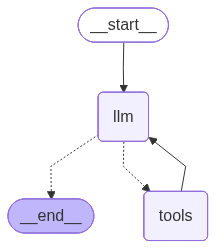

In [86]:
builder = StateGraph(ToolAgentState)

builder.add_node("llm", llm_node)
builder.add_node("tools", tools_node)

builder.add_edge(START, "llm")

builder.add_conditional_edges(
    "llm",
    should_continue,
    {
        "tools": "tools",
        END: END,
    },
)

builder.add_edge("tools", "llm")

tool_agent_graph = builder.compile()

display_graph(tool_agent_graph)

## 9.6 Executando o agente LangGraph

Agora executamos o grafo com uma pergunta inicial.

In [87]:
result = tool_agent_graph.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Sou a Ana. Veja meu progresso no curso e diga se já posso começar o A6. "
                    "Se ainda não puder, explique o que falta."
                )
            )
        ],
        "steps": 0,
    }
)

print_messages(result["messages"])


Mensagem 0 — HumanMessage

Sou a Ana. Veja meu progresso no curso e diga se já posso começar o A6. Se ainda não puder, explique o que falta.

Mensagem 1 — AIMessage

tool_calls:

[
    {
        'name': 'consultar_progresso_aluno',
        'args': {'aluno': 'Ana'},
        'id': 'call_5AvOveOMiNE4CmiEdq7OX6Td',
        'type': 'tool_call'
    }
]

Mensagem 2 — ToolMessage

{"aluno": "Ana", "email": "ana@example.com", "modulos": [{"modulo": "A4", "status": "concluido", "percentual": 100,
"observacao": "Bom domínio do grafo básico."}, {"modulo": "A5", "status": "em_andamento", "percentual": 50, 
"observacao": "Ainda revisando loops e rotas condicionais."}, {"modulo": "A6", "status": "bloqueado", "percentual":
0, "observacao": "Depende da conclusão do A5."}]}

Mensagem 3 — AIMessage

Ana, você concluiu o módulo A4, mas atualmente está com o módulo A5 em andamento, com 50% de progresso. O módulo A6
está bloqueado e depende da conclusão do A5.

Portanto, você ainda não pode começar o A6. Para prosseguir, você precisa concluir o módulo A5.

## Discussão

Agora o loop ReAct deixou de ser um `for` escrito manualmente e passou a ser um grafo explícito.

Isso traz vantagens:

- o fluxo fica visualizável;
- cada responsabilidade vira um nó;
- é possível inserir validação antes ou depois das tools;
- é possível adicionar auditoria;
- é possível controlar loops com critérios de parada;
- é possível adicionar aprovação humana antes de tools sensíveis.

# 10. Agente pronto com `create_agent`

LangChain também oferece um harness pronto para agentes.

Com `create_agent`, você informa:

- o modelo;
- a lista de tools;
- o prompt de sistema.

O loop de chamadas de modelo e tools fica encapsulado.

In [ ]:
agent = create_agent(
    model=llm,
    tools=tools_operacionais,
    system_prompt=SYSTEM_TOOLS_PROMPT,
)

Agora invocamos o agente pronto.

In [91]:
agent_result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Sou o Renan. Consulte o cronograma do A6 e monte um plano "
                    "considerando 30 minutos de estudo por dia."
                ),
            }
        ]
    }
)

print_messages(agent_result["messages"])


ConnectError: [WinError 10061] Nenhuma conexão pôde ser feita porque a máquina de destino as recusou ativamente

## Discussão

`create_agent` é útil quando você quer começar rápido.

O grafo manual com `StateGraph` é útil quando você quer controle fino sobre:

- roteamento;
- estado;
- interrupções;
- autorização;
- logging;
- recuperação de erro;
- limites de uso;
- ciclos customizados;
- integração com outros nós do seu workflow.

# 11. Boas práticas para tools

Ao construir tools para agentes, especialmente em um curso ou ambiente corporativo, alguns cuidados são importantes.

## 11.1 Nome e descrição

Use nomes claros e específicos.

Prefira:

```python
consultar_cronograma_modulo
consultar_progresso_aluno
calcular_plano_estudo
```

Evite nomes genéricos como:

```python
executar
fazer
buscar
tool1
```

## 11.2 Argumentos tipados

O schema de argumentos orienta a LLM.

Prefira argumentos explícitos:

```python
def consultar_cronograma_modulo(codigo_modulo: str) -> str:
    ...
```

## 11.3 Retorno estruturado

Quando possível, retorne JSON.

Isso facilita a interpretação pela LLM e também a depuração pela aplicação.

## 11.4 Tratamento de erro

Uma tool deve retornar erros compreensíveis.

Em vez de apenas quebrar a execução, ela pode retornar:

```json
{
  "erro": "modulo_nao_encontrado",
  "modulos_disponiveis": ["A4", "A5", "A6"]
}
```

## 11.5 Segurança e autorização

Nem toda tool deve ser executada automaticamente.

Consultar progresso pode ser seguro em um ambiente de aula controlado.

Alterar status de aluno, registrar nota ou enviar e-mail para a turma são ações sensíveis e podem exigir aprovação humana.

## 11.6 Observabilidade

Registre:

- tool solicitada;
- argumentos usados;
- resultado retornado;
- tempo de execução;
- erros;
- usuário que iniciou a interação.

Isso ajuda a depurar agentes e auditar decisões.


# 12. Exercícios de fixação

## Exercício 1 — Nova tool de material complementar

Crie uma tool chamada `buscar_material_complementar`.

Ela deve receber um módulo (`A4`, `A5` ou `A6`) e retornar uma lista de materiais recomendados.

Sugestão de retorno:

```json
{
  "modulo": "A6",
  "materiais": [
    "Documentação de tools do LangChain",
    "Exemplo de ToolMessage",
    "Exemplo de agente ReAct"
  ]
}
```


In [ ]:
# Escreva sua solução aqui.

## Exercício 2 — Tool de progresso com filtro

Modifique `consultar_progresso_aluno` ou crie uma nova tool para permitir filtrar por módulo.

Exemplo:

```python
consultar_progresso_modulo(aluno="Renan", modulo="A6")
```

A tool deve retornar apenas o status daquele módulo para aquele aluno.


In [ ]:
# Escreva sua solução aqui.

## Exercício 3 — Tratamento de tool desconhecida

No notebook, a função `executar_tool_calls` já trata tools desconhecidas.

Altere esse tratamento para incluir também:

- data/hora da falha;
- nome da tool solicitada;
- lista de tools permitidas;
- uma mensagem sugerindo que a LLM tente resolver sem aquela tool.


In [ ]:
# Escreva sua solução aqui.

## Exercício 4 — Limite de chamadas

Adicione um contador para impedir que o agente chame mais de três tools em uma única execução.

Esse controle pode ser implementado:

- no loop manual de LangChain;
- no estado do LangGraph;
- ou na função `executar_tool_calls`.


In [ ]:
# Escreva sua solução aqui.

## Exercício 5 — Aprovação humana

Crie uma tool fictícia chamada `alterar_status_aluno`.

Ela deve representar uma operação sensível, pois muda o status de um aluno no curso.

Depois, discuta como você impediria que essa tool fosse executada sem aprovação humana.

Pontos para considerar:

- a LLM pode solicitar a alteração;
- a aplicação deve validar permissões;
- o usuário ou professor pode precisar aprovar;
- a alteração deve ser registrada.


In [ ]:
# Escreva sua solução aqui.

## Exercício 6 — Comparar LangChain e LangGraph

Explique, com suas palavras, a diferença entre:

1. usar um loop ReAct manual com LangChain;
2. modelar o mesmo fluxo em LangGraph;
3. usar `create_agent`.

Na resposta, considere:

- controle do estado;
- transparência do fluxo;
- facilidade de manutenção;
- flexibilidade para adicionar etapas do curso, como avaliação, feedback e aprovação humana.


In [ ]:
# Escreva sua resposta aqui.

# 13. Resumo da aula

Neste notebook, vimos como agentes podem interagir com ferramentas externas.

Os pontos principais foram:

- tools são funções expostas ao modelo com nome, descrição e schema;
- a LLM não executa tools diretamente;
- a LLM retorna `tool_calls` dentro de uma `AIMessage`;
- a aplicação executa as funções Python correspondentes;
- o resultado da execução é devolvido como `ToolMessage`;
- a LLM interpreta a `ToolMessage` para gerar uma resposta final;
- esse padrão compõe o ciclo ReAct: raciocínio, ação, observação e resposta;
- LangChain permite montar esse fluxo manualmente;
- LangGraph permite transformar o fluxo em um grafo explícito;
- `create_agent` oferece uma abstração pronta para casos comuns.

No contexto do curso de LangGraph, as tools permitiram que o agente:

- consultasse o cronograma dos módulos A4, A5 e A6;
- verificasse o progresso de alunos;
- calculasse planos de estudo personalizados.


## 13.1 Checklist de compreensão

Antes de avançar, verifique se você consegue responder:

1. O que é uma tool em LangChain?
2. O que é `AIMessage.tool_calls`?
3. O que é uma `ToolMessage`?
4. Quem realmente executa a tool?
5. Por que a LLM não deve inventar dados do cronograma ou do progresso do aluno?
6. Como o resultado de uma tool volta para a LLM?
7. Como um loop ReAct alterna entre LLM e tools?
8. Como o LangGraph representa esse loop?
9. Qual a vantagem de controlar o fluxo explicitamente em um grafo?
10. Quando faz sentido usar `create_agent`?


## 13.2 Próximos passos

A partir daqui, você pode evoluir o agente do curso de LangGraph para incluir:

- múltiplas tools de consulta acadêmica;
- memória de curto prazo do aluno;
- histórico de dúvidas;
- recomendação automática de revisão;
- aprovação humana para mudanças de status;
- persistência do estado do grafo;
- logs de tool calls;
- avaliação automática de respostas do aluno;
- integração com APIs reais.


# 14. Referências

- LangChain — Tools: https://docs.langchain.com/oss/python/langchain/tools
- LangChain — Messages e `ToolMessage`: https://docs.langchain.com/oss/python/langchain/messages
- LangChain — Agents: https://docs.langchain.com/oss/python/langchain/agents
- LangGraph — Quickstart com tool node: https://docs.langchain.com/oss/python/langgraph/quickstart
- LangChain — ChatOllama integration: https://docs.langchain.com/oss/python/integrations/chat/ollama
- Padrão ReAct: reasoning and acting em agentes baseados em LLM.
- Notebooks anteriores da sequência: A4 e A5.
